In [1]:
# Importing all the Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings 
warnings.filterwarnings('ignore')

In [2]:
# Lets see what is in the Data
df=pd.read_csv(r"C:\Users\jahnv\Downloads\archive\Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Description:
The various features of the cleaned dataset are explained below:

Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.

Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.

Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.

Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.

Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.

Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.

Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.

Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.

Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.

Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.

Price: Target variable stores information of the ticket price.

In [3]:
# Droping the useless column 'Unnamed: 0'
df=df.drop('Unnamed: 0',axis=1)

In [4]:
# A Quick Information abou the Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [5]:
# Stastical Description of Data
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
# Size of the data 
df.shape

(300153, 11)

In [7]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

<b> Indigo becaming as a most popular Airline

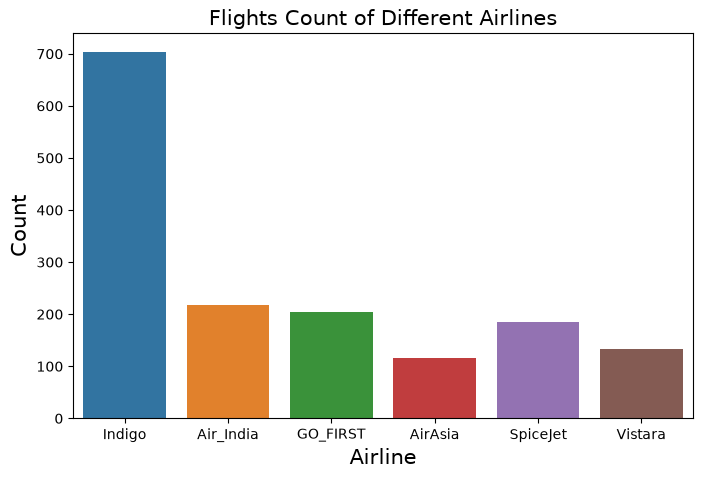

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df1,
    x='airline',
    palette='tab10'
)

plt.title('Flights Count of Different Airlines', fontsize=15)
plt.xlabel('Airline', fontsize=15)
plt.ylabel('Count', fontsize=15)

plt.show()

In [9]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

<b> Most of the Airlines has Economic Class as common

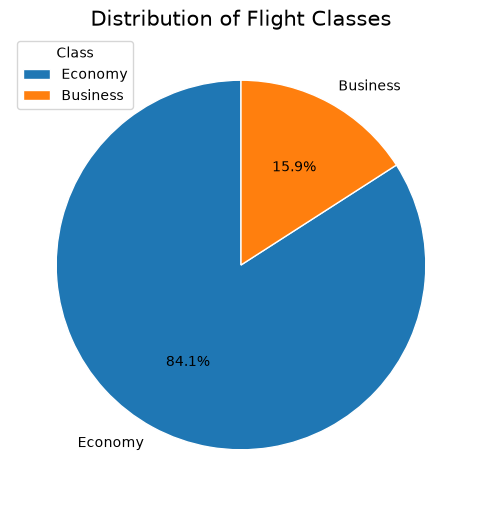

In [10]:
plt.figure(figsize=(8,6))

df2['class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('tab10'),
    textprops={'color': 'black'},
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribution of Flight Classes', fontsize=15)
plt.ylabel('')   
plt.legend(title='Class', labels=['Economy', 'Business'], loc='best')

plt.show()

<b> Does price vary with Airlines?</b>

<p>
    
<ul>
    <li>As we can see Vistara has Maximum Price range</li>
    <li>Vistara and Air_India Airlines Have Maximum Price when compared to Others</li>
    <li>SpiceJet , AirAsia , GO_First and Indigo has some what equal prices</li>  
    
</ul>
</p>

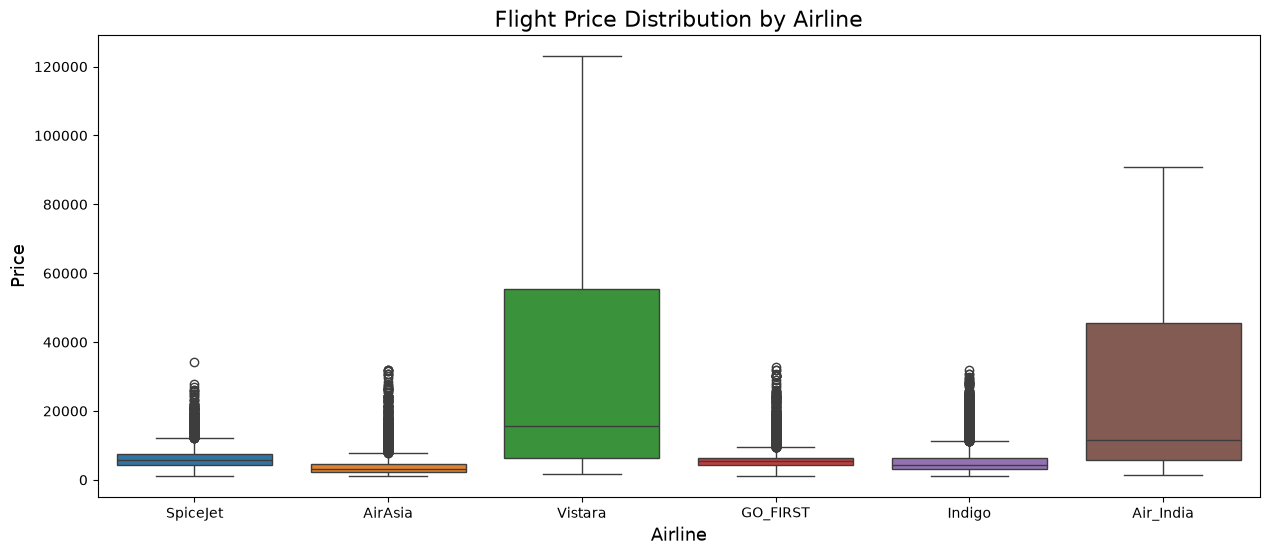

In [11]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x='airline',
    y='price',
    palette='tab10'
)

plt.title('Flight Price Distribution by Airline', fontsize=16)
plt.xlabel('Airline', fontsize=13)
plt.ylabel('Price', fontsize=13)


plt.show()

<p>
    <b> How Does the Ticket Price vary between Economy and Business Class?</b>
   
<ul> 
    <li>Ticket Price is Maximum for Bussiness Class When compared to Economy Class</li>
</ul>
    </p>

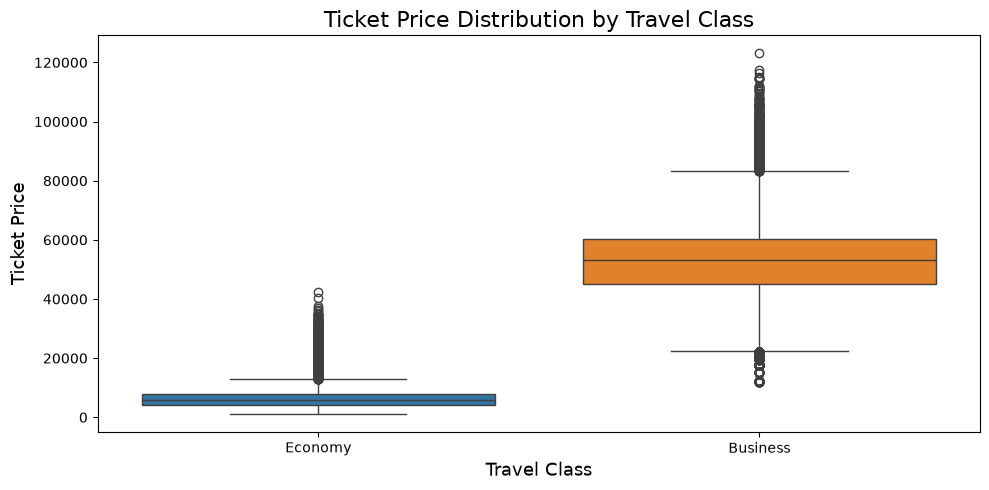

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='class',
    y='price',
    palette='tab10'
)

plt.title('Ticket Price Distribution by Travel Class', fontsize=16)
plt.xlabel('Travel Class', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

<b> How Does the Ticket Price vary with the number of stops of a Flight?</b>

<p> 
<ul><li>Flights having one stop has maximum ticket price</li></ul>
</p>

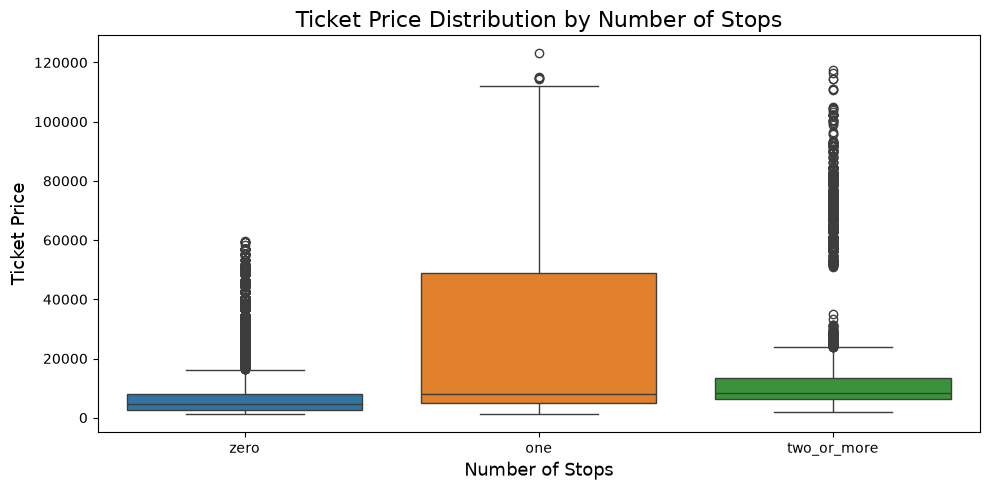

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='stops',
    y='price',
    palette='tab10'
)

plt.title('Ticket Price Distribution by Number of Stops', fontsize=16)
plt.xlabel('Number of Stops', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

<p>
    
<b> How the Ticket Price change based on the Departure Time and Arrival Time?</b><br>

    
<b>1. Departure Time Vs Ticket Price</b>

   <ul>
   <li> Ticket Price is More for the Flights when the Departure Time is at Night</li>
   <li>Ticket Price is almost equal for flights Having Departure time at Early_morning , Morning and Evening</li>
   <li>Ticket Price is Low for the Flights Having Departure Time at Late_night</li>
   </ul>
    
 
 
<b>2. Arrival Time Vs Ticket Price</b>

   <ul>
    <li>Ticket Price is More for the Flights when the Arrival Time is at Evening</li>
    <li>Ticket Price is almost equal for flights Having Arrival time is at Morning and Night</li>
   <li>Ticket Price is Low for the Flights Having Arrival Time at Late_night as same as Departure Time</li>
    </ul>
 </p>

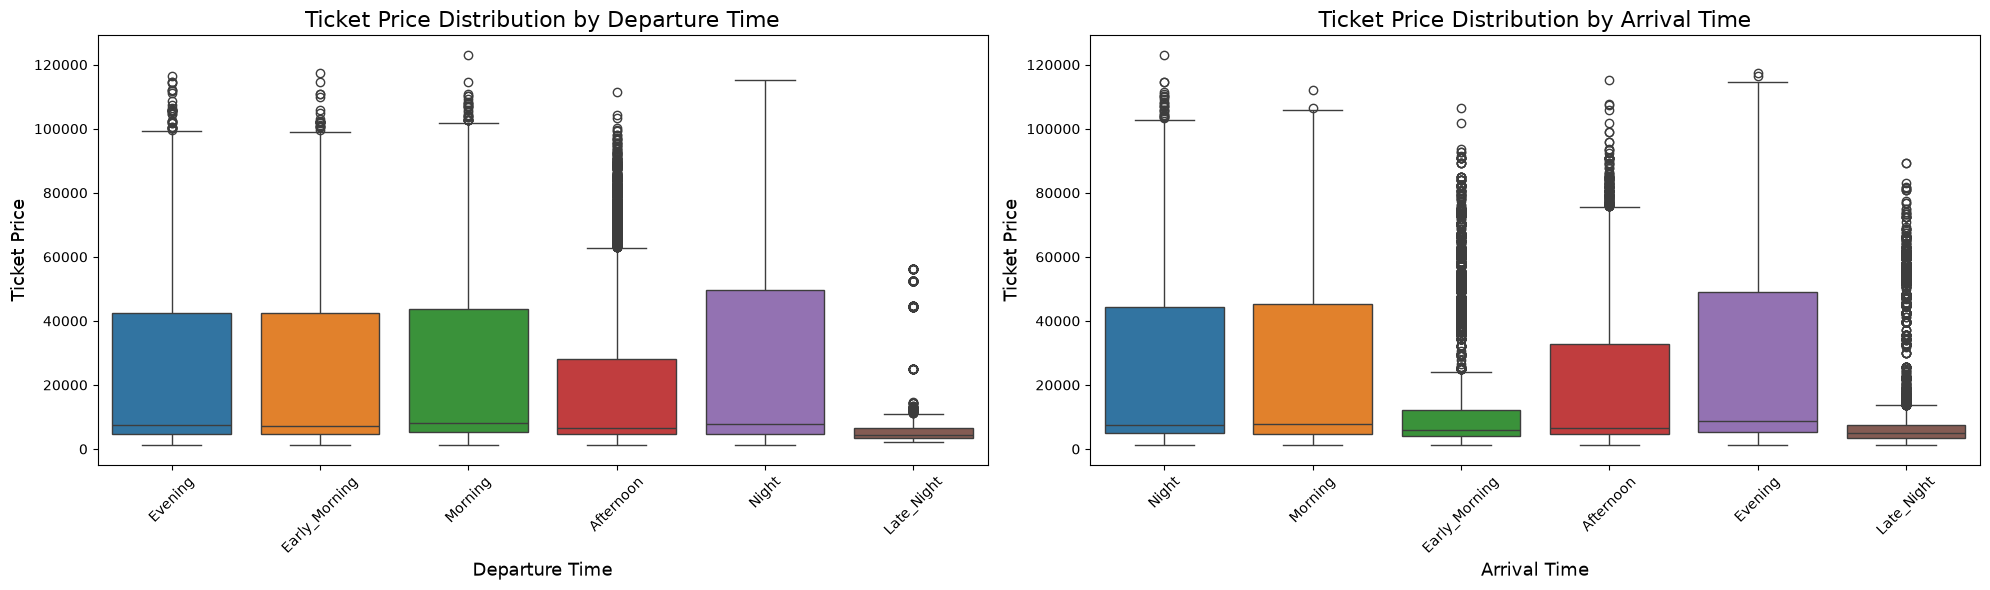

In [14]:
plt.figure(figsize=(20,6))

# Departure Time vs Ticket Price
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    x='departure_time',
    y='price',
    palette='tab10'
)
plt.title('Ticket Price Distribution by Departure Time', fontsize=16)
plt.xlabel('Departure Time', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)
plt.xticks(rotation=45)

# Arrival Time vs Ticket Price
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    x='arrival_time',
    y='price',
    palette='tab10'
)
plt.title('Ticket Price Distribution by Arrival Time', fontsize=16)
plt.xlabel('Arrival Time', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<p>
<b> How the price changes with change in Source city and Destination city?</b><br>
    
<b>1. Source City Vs Ticket Price</b>

   <li> Ticket Price is More for the Flights whose Source City is Kolkata</li>
   <li>Ticket Price is almost equal for flights Having Source Cities as Mumbai and chennai , Hyderabad and Bangalore</li>
    <li> Ticket Price is Low for the Flights Having Source City as Delhi</li>
    
 
<b>2. Destination City Vs Ticket Price</b>

   <li> Ticket Price is More for the Flights whose Destination City is kolkata and Chennai</li>
   <li> Ticket Price is almost equal for flights Having Destination Cities as Mumbai and Bangalore</li>
   <li>Ticket Price is Low for the Flights Having Destination City as Delhi</li>
</p>

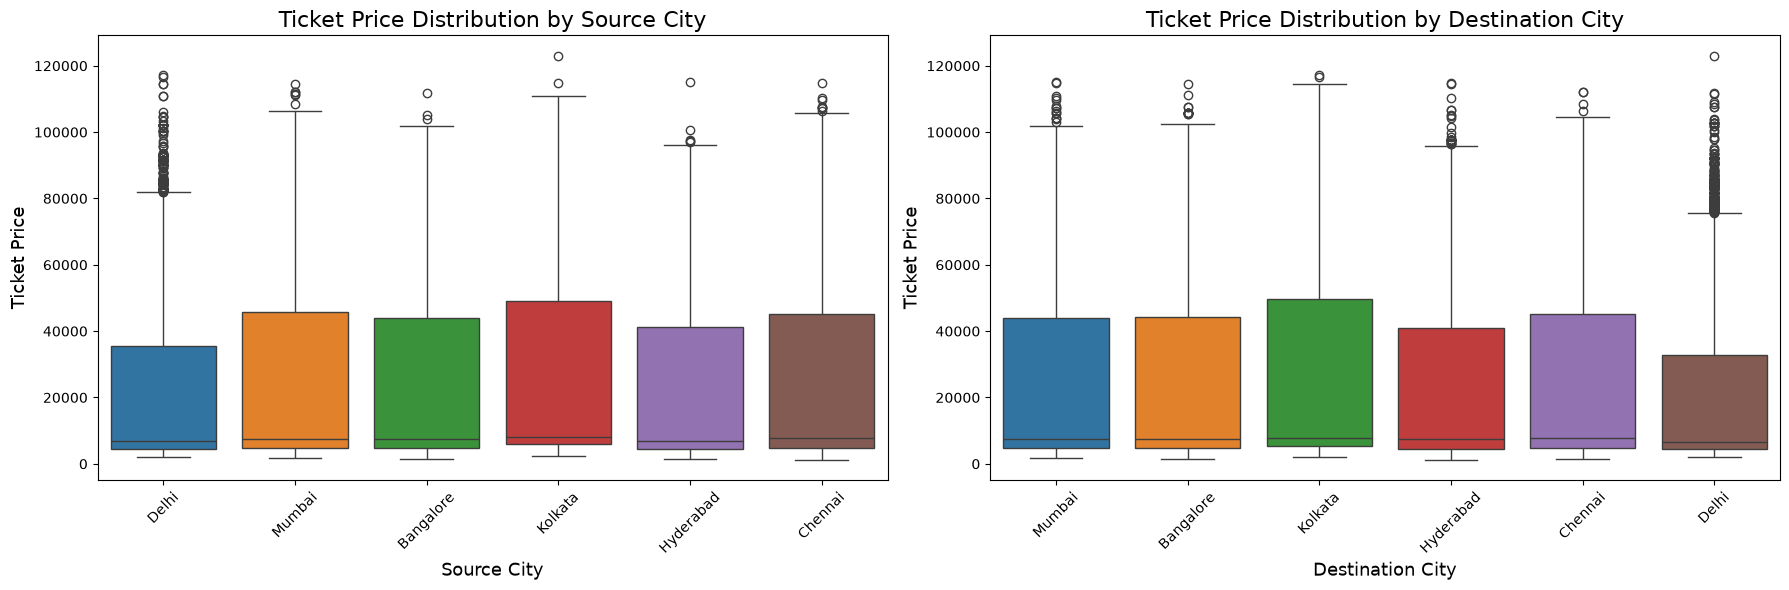

In [15]:
plt.figure(figsize=(18,6))

# Source City vs Ticket Price
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    x='source_city',
    y='price',
    palette='tab10'
)

plt.title('Ticket Price Distribution by Source City', fontsize=16)
plt.xlabel('Source City', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)
plt.xticks(rotation=45)

# Destination City vs Ticket Price
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    x='destination_city',
    y='price',
    palette='tab10'
)

plt.title('Ticket Price Distribution by Destination City', fontsize=16)
plt.xlabel('Destination City', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<p>
    <b> How Price Varies with the Flight Duration Based on Class?</b>

<li> With increase in Duration, the Ticket Price is also Increases In both the Economy and Business classes</li>
</p>


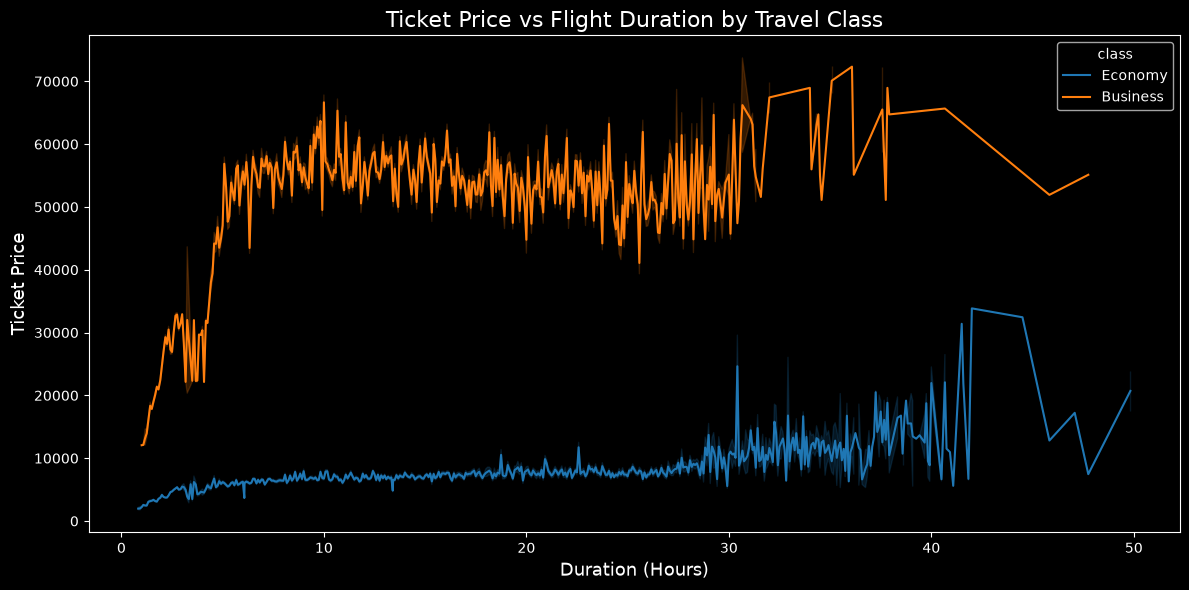

In [16]:
plt.style.use('dark_background')
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='duration',
    y='price',
    hue='class',
    palette='tab10'
)

plt.title('Ticket Price vs Flight Duration by Travel Class', fontsize=16)
plt.xlabel('Duration (Hours)', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

<p>
    <b> How does the price affected on the days left for Departure?</b>
    
<li> As we can see when compared to others when there are two days remaining for departure then the Ticket Price is very High for all airlines</li>
    
</p>

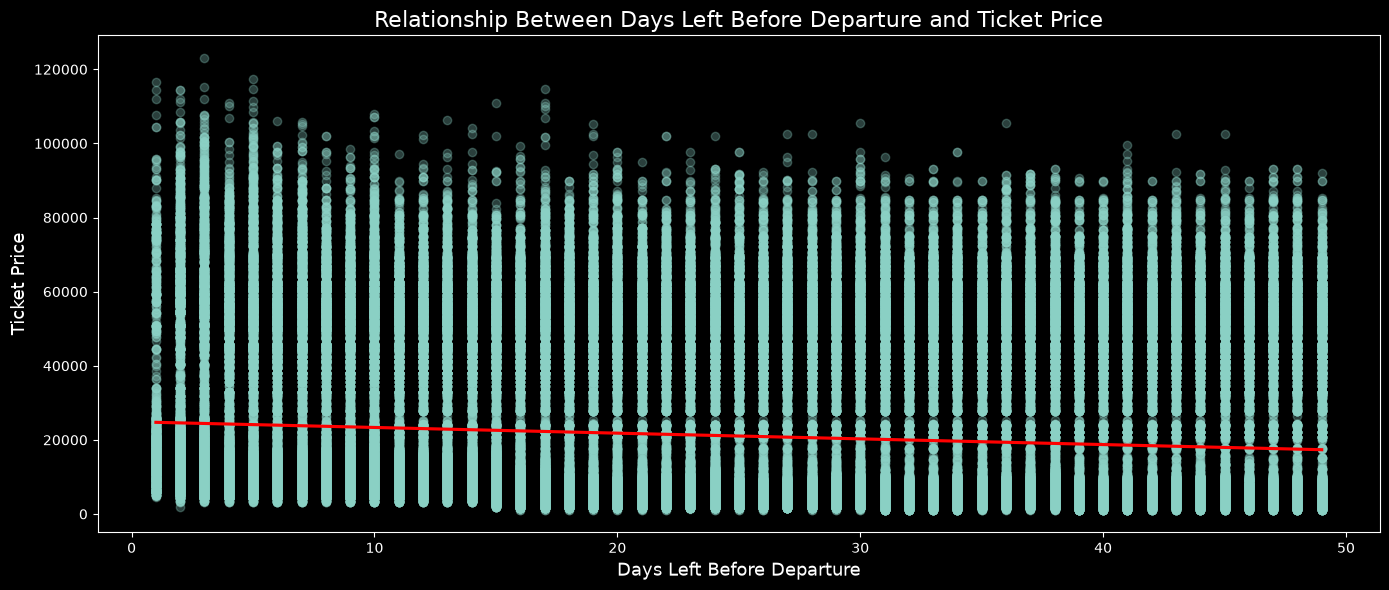

In [17]:
plt.figure(figsize=(14,6))

sns.regplot(
    data=df,
    x='days_left',
    y='price',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Relationship Between Days Left Before Departure and Ticket Price', fontsize=16)
plt.xlabel('Days Left Before Departure', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

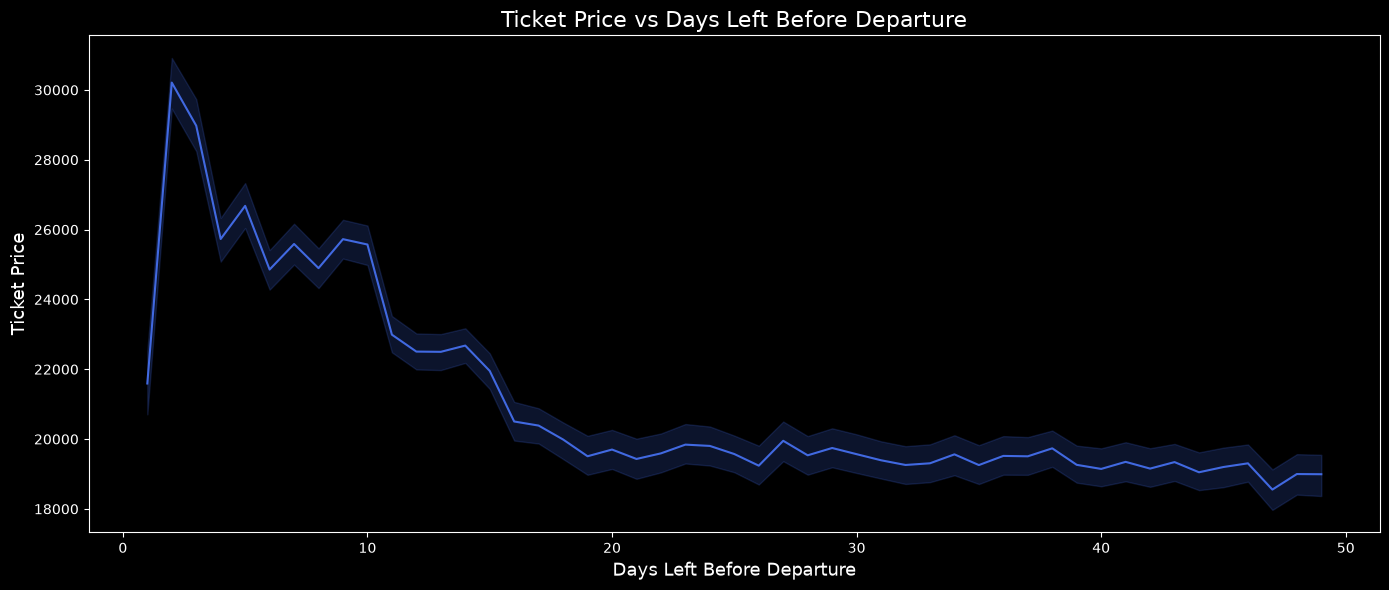

In [18]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='days_left',
    y='price',
    color='royalblue'
)

plt.title('Ticket Price vs Days Left Before Departure', fontsize=16)
plt.xlabel('Days Left Before Departure', fontsize=13)
plt.ylabel('Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

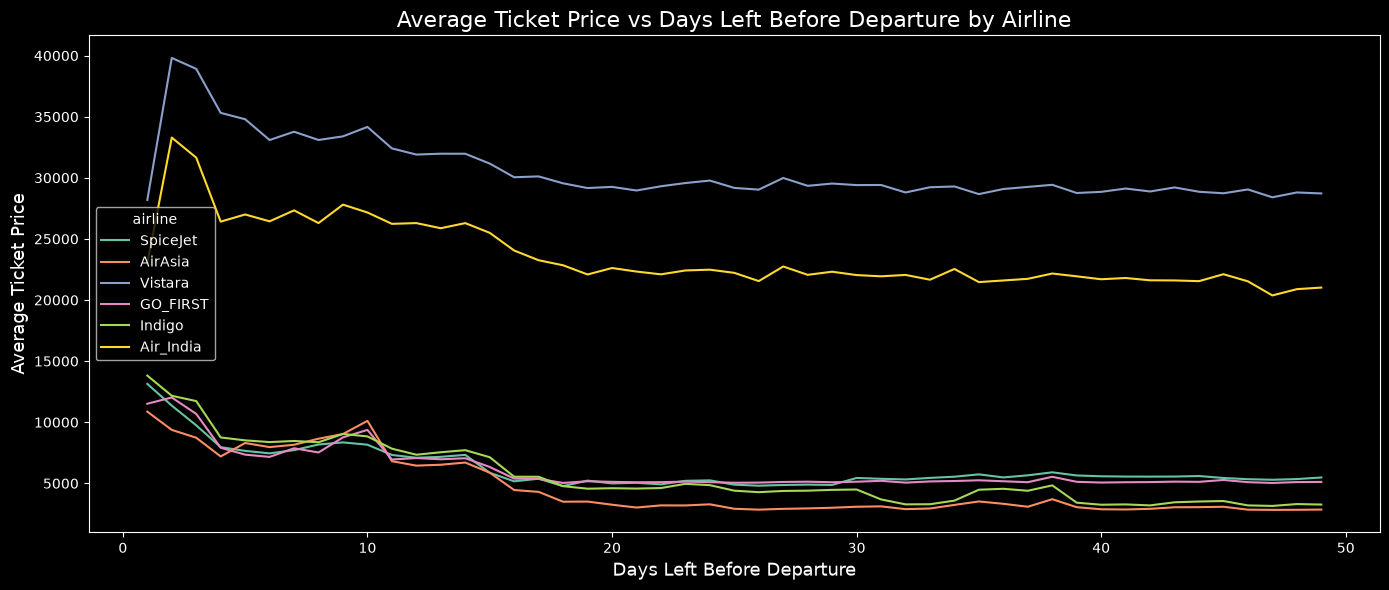

In [19]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='days_left',
    y='price',
    hue='airline',
    palette='Set2',
    estimator='mean',
    errorbar=None
)

plt.title('Average Ticket Price vs Days Left Before Departure by Airline', fontsize=16)
plt.xlabel('Days Left Before Departure', fontsize=13)
plt.ylabel('Average Ticket Price', fontsize=13)

plt.tight_layout()
plt.show()

<b> Total number of Flights from one city to another</b>

In [20]:
df.groupby(['flight','source_city','destination_city','airline','class'],as_index=False).count().groupby(['source_city','destination_city'],as_index=False)['flight'].count().head(10)

,source_city,destination_city,flight
0,Bangalore,Chennai,106
1,Bangalore,Delhi,227
2,Bangalore,Hyderabad,132
3,Bangalore,Kolkata,171
4,Bangalore,Mumbai,175
5,Chennai,Bangalore,69
6,Chennai,Delhi,105
7,Chennai,Hyderabad,82
8,Chennai,Kolkata,110
9,Chennai,Mumbai,94


<b> Average Price of different Airlnes from Source city to Destination city</b>

In [21]:
df.groupby(['airline','source_city','destination_city'],as_index=False)['price'].mean().head(10)


,airline,source_city,destination_city,price
0,AirAsia,Bangalore,Chennai,2073.043478
1,AirAsia,Bangalore,Delhi,4807.092426
2,AirAsia,Bangalore,Hyderabad,2931.494792
3,AirAsia,Bangalore,Kolkata,4443.468160
4,AirAsia,Bangalore,Mumbai,3342.385350
5,AirAsia,Chennai,Bangalore,1914.760870
6,AirAsia,Chennai,Delhi,3697.314003
7,AirAsia,Chennai,Hyderabad,2053.182540
8,AirAsia,Chennai,Kolkata,3682.338762
9,AirAsia,Chennai,Mumbai,2691.100000


In [22]:
# Creating a Back up File
df_bk=df.copy()

In [23]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\jahnv\AppData\Local\Programs\Python\Python313\python.exe
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [24]:
# Coverting the labels into a numeric form using Label Encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [25]:
# storing the Dependent Variables in X and Independent Variable in Y
x=df.drop(['price'],axis=1)
y=df['price']

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42
)

In [30]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [31]:
x = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [32]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42
)

In [33]:
from sklearn.preprocessing import MinMaxScaler

mmscaler = MinMaxScaler(feature_range=(0,1))

x_train = mmscaler.fit_transform(x_train)
x_test = mmscaler.transform(x_test)

In [34]:
a={'Model Name':[], 'Mean_Absolute_Error_MAE':[] ,'Adj_R_Square':[] ,'Root_Mean_Squared_Error_RMSE':[] ,'Mean_Absolute_Percentage_Error_MAPE':[] ,'Mean_Squared_Error_MSE':[] ,'Root_Mean_Squared_Log_Error_RMSLE':[] ,'R2_score':[]}
Results=pd.DataFrame(a)
Results.head()

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score


In [37]:
import numpy as np
import pandas as pd
from sklearn import metrics


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.1,
        n_estimators=100,
        random_state=42
    ),
    
    "Bagging": BaggingRegressor(random_state=42),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.1)
}


Results = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "RMSLE",
    "MAPE",
    "R2 Score",
    "Adjusted R2"
])



def MAPE(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100



for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    rmsle = np.log(rmse)
    r2 = metrics.r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    adj_r2 = 1 - (1-r2)*(len(y)-1)/(len(y)-x.shape[1]-1)

    print("="*80)
    print(name)
    print("="*80)
    print("MAE :", round(mae,3))
    print("MSE :", round(mse,3))
    print("RMSE :", round(rmse,3))
    print("RMSLE :", round(rmsle,3))
    print("MAPE :", round(mape,2),"%")
    print("R2 Score :", round(r2,4))
    print("Adjusted R2 :", round(adj_r2,4))

    Results.loc[len(Results)] = [
        name,
        mae,
        mse,
        rmse,
        rmsle,
        mape,
        r2,
        adj_r2
    ]


Results = Results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

Results

Linear Regression
MAE : 4623.409
MSE : 49062056.15
RMSE : 7004.431
RMSLE : 8.854
MAPE : 43.66 %
R2 Score : 0.9047
Adjusted R2 : 0.9047
Decision Tree
MAE : 910.927
MSE : 8900834.782
RMSE : 2983.427
RMSLE : 8.001
MAPE : 6.21 %
R2 Score : 0.9827
Adjusted R2 : 0.9827
Random Forest
MAE : 890.595
MSE : 5614916.711
RMSE : 2369.582
RMSLE : 7.77
MAPE : 6.0 %
R2 Score : 0.9891
Adjusted R2 : 0.9891
KNN
MAE : 1831.98
MSE : 14148331.074
RMSE : 3761.427
RMSLE : 8.233
MAPE : 11.03 %
R2 Score : 0.9725
Adjusted R2 : 0.9725
Extra Trees
MAE : 942.321
MSE : 6517351.039
RMSE : 2552.91
RMSLE : 7.845
MAPE : 6.4 %
R2 Score : 0.9873
Adjusted R2 : 0.9873
Gradient Boosting
MAE : 2789.787
MSE : 22075398.324
RMSE : 4698.446
RMSLE : 8.455
MAPE : 20.41 %
R2 Score : 0.9571
Adjusted R2 : 0.9571
Bagging
MAE : 919.363
MSE : 6070153.303
RMSE : 2463.768
RMSLE : 7.809
MAPE : 6.27 %
R2 Score : 0.9882
Adjusted R2 : 0.9882
Ridge
MAE : 4623.427
MSE : 49062012.8
RMSE : 7004.428
RMSLE : 8.854
MAPE : 43.66 %
R2 Score : 0.9047
Adj

,Model,MAE,MSE,RMSE,RMSLE,MAPE,R2 Score,Adjusted R2
0,Random Forest,890.594651,5.614917e+06,2369.581548,7.770469,5.996278,0.989090,0.989090
1,Bagging,919.363321,6.070153e+06,2463.768111,7.809447,6.265182,0.988206,0.988205
2,Extra Trees,942.320533,6.517351e+06,2552.910308,7.844989,6.399769,0.987337,0.987336
3,Decision Tree,910.927382,8.900835e+06,2983.426685,8.000828,6.211268,0.982706,0.982705
4,KNN,1831.979948,1.414833e+07,3761.426734,8.232554,11.025938,0.972510,0.972509
5,Gradient Boosting,2789.786562,2.207540e+07,4698.446373,8.454987,20.411115,0.957107,0.957106
6,Lasso,4623.301220,4.906198e+07,7004.425521,8.854297,43.660725,0.904672,0.904669
7,Ridge,4623.427359,4.906201e+07,7004.428085,8.854298,43.663821,0.904672,0.904669
8,Linear Regression,4623.408800,4.906206e+07,7004.431180,8.854298,43.663631,0.904672,0.904669


In [38]:
Results


,Model,MAE,MSE,RMSE,RMSLE,MAPE,R2 Score,Adjusted R2
0,Random Forest,890.594651,5.614917e+06,2369.581548,7.770469,5.996278,0.989090,0.989090
1,Bagging,919.363321,6.070153e+06,2463.768111,7.809447,6.265182,0.988206,0.988205
2,Extra Trees,942.320533,6.517351e+06,2552.910308,7.844989,6.399769,0.987337,0.987336
3,Decision Tree,910.927382,8.900835e+06,2983.426685,8.000828,6.211268,0.982706,0.982705
4,KNN,1831.979948,1.414833e+07,3761.426734,8.232554,11.025938,0.972510,0.972509
5,Gradient Boosting,2789.786562,2.207540e+07,4698.446373,8.454987,20.411115,0.957107,0.957106
6,Lasso,4623.301220,4.906198e+07,7004.425521,8.854297,43.660725,0.904672,0.904669
7,Ridge,4623.427359,4.906201e+07,7004.428085,8.854298,43.663821,0.904672,0.904669
8,Linear Regression,4623.408800,4.906206e+07,7004.431180,8.854298,43.663631,0.904672,0.904669


<p> From the Above Results, The Top 3 Models by comparing Errors , Adj_R_Square and R2_Score values are<br>
    
1. <b>ExtraTreesRegressor</b>
2. <b>RandomForestRegressor</b>
3. <b>Bagging Regressor</b><br>

<p>Training the Data with <b>ExtraTreesRegressor</b></p>
</p>

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,3))
print("Mean Squared Error (MSE):", round(mse,3))
print("Root Mean Squared Error (RMSE):", round(rmse,3))
print("R2 Score:", round(r2,4))

Mean Absolute Error (MAE): 4623.301
Mean Squared Error (MSE): 49061976.874
Root Mean Squared Error (RMSE): 7004.426
R2 Score: 0.9047


In [46]:
from sklearn.ensemble import ExtraTreesRegressor

modelETR = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

In [47]:
# Train the model
modelETR.fit(x_train, y_train)

# Predict on test data
y_pred = modelETR.predict(x_test)

In [48]:
out=pd.DataFrame({'Price_actual':y_test,'Price_pred':y_pred})
result=df_bk.merge(out,left_index=True,right_index=True)

In [49]:
result.sample(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,Price_actual,Price_pred
199405,Vistara,UK-838,Chennai,Night,one,Night,Kolkata,Economy,25.67,18,5937,5937,6017.42
202736,Indigo,6E-847,Chennai,Evening,one,Night,Hyderabad,Economy,3.92,3,11867,11867,8562.31
105927,Vistara,UK-858,Bangalore,Early_Morning,one,Evening,Kolkata,Economy,10.17,24,7683,7683,7101.60
177289,Air_India,AI-9885,Hyderabad,Morning,two_or_more,Morning,Chennai,Economy,22.17,14,13446,13446,13436.82
224950,Air_India,AI-491,Delhi,Morning,two_or_more,Morning,Chennai,Business,22.92,49,52728,52728,53446.93
49150,Vistara,UK-821,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,6.75,32,4909,4909,4909.00
244490,Vistara,UK-950,Mumbai,Night,one,Evening,Chennai,Business,18.42,43,61933,61933,61981.02
3094,Air_India,AI-762,Delhi,Night,one,Night,Mumbai,Economy,23.83,17,6737,6737,7270.81
177362,Air_India,AI-840,Hyderabad,Night,one,Evening,Chennai,Economy,22.17,15,11446,11446,10882.27
32311,AirAsia,I5-798,Delhi,Afternoon,one,Evening,Hyderabad,Economy,6.58,29,2050,2050,2106.72


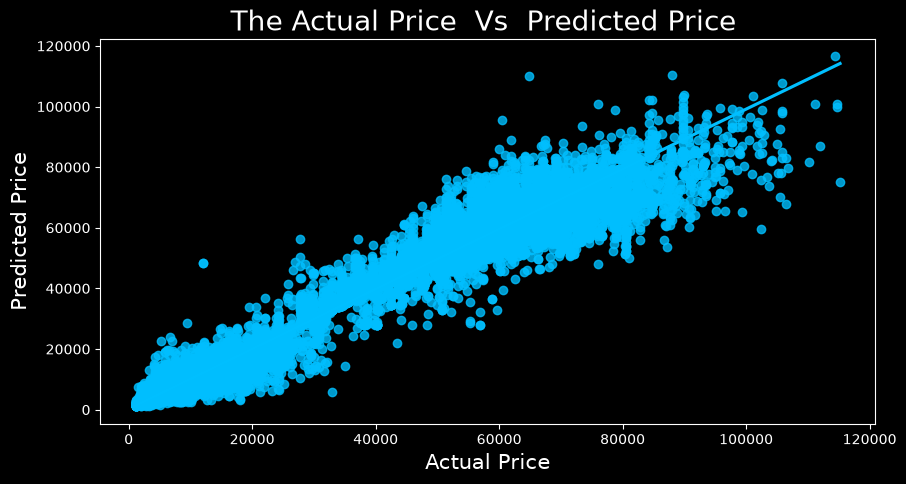

In [52]:
plt.figure(figsize=(10,5))
sns.regplot(x='Price_actual',y='Price_pred',data=result,color='deepskyblue')
plt.title('The Actual Price  Vs  Predicted Price ',fontsize=20)
plt.xlabel('Actual Price',fontsize=15)
plt.ylabel('Predicted Price',fontsize=15)
plt.show()